## Stochastic logistic growth process:

$$
    x_t = x_{t-1} + r\, x_{t-1}\!\left(1 - \frac{x_{t-1}}{k}\right) +
    x_{t-1}\,\varepsilon_t, \quad \varepsilon_t \sim
    \mathcal{N}(0,\sigma^2_{\mathrm{log}}),
$$

with parameters $r = 0.22$, $k = 10$, $\sigma_{\mathrm{log}} = 0.18$,
initial condition $x_0 = 0.8$, and time horizon $T = 50$.

We evaluate the following past LTL property, which combines a safety condition
over the first part of the trajectory with a safety condition over the
final steps:
$$
    \varphi_{\mathrm{log}} = H_{[10,5
    0]}(x < k) \wedge H_{[0,10]}(x > k).
$$

In [7]:
import torch
from torch.nn.functional import threshold
import numpy as np

from models import ou_model, logistic_model, simulate, plot_traj_set

1) Monte Carlo simulations

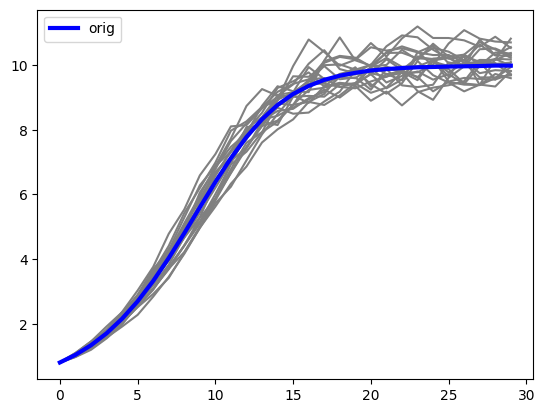

In [12]:
# logistic growth  process
# X_{t+1} = X_t + r * X_t * (1 - X_t/k)  + X_t *sqrt(k)*sigma*ep;  eps~normal(0,1)

time_steps = 30

#slower convergence to x=2, higher variance
params2 = {'time': time_steps,      # time steps
            'init_x':0.8,  # initial x
            'r': 0.32,        #
            'k': 10.0,        #
            'sigma': 0.18}



trajs = simulate(logistic_model, 10000, params2)

plot_traj_set(trajs, single_traj=20, color='blue', label='orig')

In [13]:
t = 20

pre = torch.prod(trajs[:,:t]<10.0, dim=1)
post = trajs[:,t] >= 10.0
reach = pre * post
reach.float().mean()


tensor(0.1147, dtype=torch.float32)

In [14]:
thr = 10.5
reach = torch.max(trajs, dim=1).values  > thr
p_ev = reach.float().mean()
print("eventually reach",p_ev)




eventually reach tensor(0.4881, dtype=torch.float32)


In [15]:
# sometimes[0,b] historically |x - 10|  <= 1
threshold = 10
reach_int  = 1.0
#aromic proposition
atom = (torch.abs(trajs - threshold) <= reach_int).int()

# historically [t,T] atom same as globally atom
historically = torch.flip(torch.cumprod(torch.flip(atom, dims=[1]), dim=1), dims=[1])
#eventually[0,b]  globally atom
sometimes = torch.cummax(historically, dim=1).values

truth_probability = sometimes.float().mean(dim=0)
#b = 30
truth_probability[29]

tensor(0.9770, dtype=torch.float32)

In [16]:
# compute the same probability using the trajectories trajs
trajs_first_20 = trajs[:, :20]
trajs_last_10 = trajs[:, 20:30]

first_20 = (trajs_first_20 < 10).all(dim=1).float().mean()
last_10 = (trajs_last_10 > 10).all(dim=1).float().mean()

print("P(all first 20 < 10) via MC:", first_20.item())
print("P(all last 10 > 10) via MC:", last_10.item())

total_prob = first_20 * last_10
print("Joint probability via MC:", total_prob.item())


P(all first 20 < 10) via MC: 0.5920000076293945
P(all last 10 > 10) via MC: 0.026000000536441803
Joint probability via MC: 0.015392000786960125


In [17]:
# Compute 95% confidence interval for total_prob 
# using the standard error of a proportion
n = trajs.shape[0]  # number of trajectories
p = total_prob.item()  # estimated probability
se = np.sqrt(p * (1 - p) / n)  # standard error
ci_lower = p - 1.96 * se  # lower bound of 95% CI
ci_upper = p + 1.96 * se  # upper bound of 95% CI
print(f"95% confidence interval for total_prob: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% confidence interval for total_prob: [0.0130, 0.0178]


In [4]:
# import module optimization to use DeGAS
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

from optimization import *
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

Monitor Variables

In [10]:
compiledFile = compile2SOGA('logistic_MV.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)
output_dist = start_SOGA(cfg)

In [ ]:
print(output_dist.gm.mean()[output_dist.var_list.index('phi')])

tensor(0.0401)


Direct Integration


In [30]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('logistic.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)
output_dist = start_SOGA(cfg)

In [31]:
mu = output_dist.gm.mu[0,:time_steps]
sigma = output_dist.gm.sigma[0,:time_steps,:time_steps]

In [32]:
# computing the prob of being below 10 in the first 40 time instants and above then in the last 10 time instants.
A = torch.clone(mu)
B = torch.clone(mu)
A[:20] = -torch.inf
B[:20] = 10.0
A[20:] = 10.0
B[20:] = torch.inf

print(sigma.shape)
print(mu.shape)

torch.Size([30, 30])
torch.Size([30])


In [33]:
p = ghk_mvnorm_prob(mu, sigma, A, B, n_samples=50000)
print(p)

tensor(0.0083)


In [34]:
#calcolo la reachability di X>10 esattamente  al tempo 20.
#la costante di normalizzazione. devo essere sotto 10 fino al tempo 19, marginalizzo sul tempo 20.
t = 20
A[:t+1] = -torch.inf
B[:t] = 10.0
B[t] = torch.inf
c = ghk_mvnorm_prob(mu[:t+1], sigma[:t+1,:t+1], A[:t+1], B[:t+1], n_samples=50000)
print("normalization constant",c.item())
A[t] = 10.0
B[t] = torch.inf
pj = ghk_mvnorm_prob(mu[:t+1], sigma[:t+1,:t+1], A[:t+1], B[:t+1], n_samples=50000)
print("joint reach",pj.item())
p = pj/c
print("reach prob",p.item())

normalization constant 0.5804860491646312
joint reach 0.1091769323881099
reach prob 0.18807847758826382


In [35]:
time = 30
thr = 10.5
A = torch.clone(mu)
B = torch.clone(mu)
pt = torch.clone(mu)
for t in range(time):
    A[:t] = -torch.inf
    B[:t] = thr
    A[t] = thr
    B[t] = torch.inf
    pt[t] = ghk_mvnorm_prob(mu[:t+1], sigma[:t+1,:t+1], A[:t+1], B[:t+1], n_samples=50000)
p = pt.sum(dim=0)
print(pt)
print(p)




tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        6.9739e-14, 9.2058e-08, 2.0351e-05, 5.8142e-04, 3.8888e-03, 1.2210e-02,
        2.3447e-02, 3.3184e-02, 3.9831e-02, 4.3773e-02, 4.5287e-02, 4.4828e-02,
        4.3183e-02, 4.1526e-02, 3.9242e-02, 3.7185e-02, 3.5453e-02, 3.2997e-02])
tensor(0.4766)


In [36]:
# using output_dist.gm for probability calculation via ghk_mvnorm_prob
# Compute P(all first 40 < 10) AND P(all last 10 > 10)

# Extract mean and covariance for the full trajectory
mu_full = output_dist.gm.mu[0, :time_steps]
sigma_full = output_dist.gm.sigma[0, :time_steps, :time_steps]

# Set up bounds for first 40: -inf < X < 10
A = torch.full_like(mu_full, -torch.inf)
B = torch.full_like(mu_full, torch.inf)
A[:20] = -torch.inf
B[:20] = 10.0

# Compute P(all first 20 < 10)
first_20 = ghk_mvnorm_prob(mu_full[:20], sigma_full[:20, :20], A[:20], B[:20], n_samples=50000)

# Set up bounds for last 10: 10 < X < inf
A_last = torch.full_like(mu_full[20:30], -torch.inf)
B_last = torch.full_like(mu_full[20:30], torch.inf)
A_last[:10] = 10.0
B_last[:10] = torch.inf

# Compute P(all last 10 > 10)
last_10 = ghk_mvnorm_prob(mu_full[20:30], sigma_full[20:30, 20:30], A_last, B_last, n_samples=50000)

print("P(all first 20 < 10) via GHK:", first_20.item())
print("P(all last 10 > 10) via GHK:", last_10.item())

total_prob = first_20 * last_10
print("Joint probability via GHK:", total_prob.item())


P(all first 20 < 10) via GHK: 0.5826989510230326
P(all last 10 > 10) via GHK: 0.03080036226072376
Joint probability via GHK: 0.017947338780453136


In [37]:
last_10 = output_dist.gm.marg_ccdf(torch.full((10,), 10.0), idx = list(range(20, 30)))
first_20 = output_dist.gm.marg_cdf(torch.full((20,), 10.0), idx = list(range(0, 20)))

total_prob_marg = first_20 * last_10

print("P(all first 20 < 10) via marg_cdf:", first_20.item())
print("P(all last 10 > 10) via marg_ccdf:", last_10.item())
print("Joint probability via marginals:", total_prob_marg.item())


P(all first 20 < 10) via marg_cdf: 0.6235321756704066
P(all last 10 > 10) via marg_ccdf: 0.03582636036129368
Joint probability via marginals: 0.02233888842242946


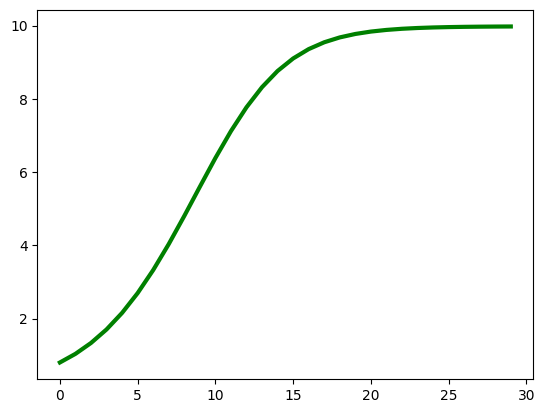

In [38]:
T = 30
#output_dist
plt.plot(range(T), output_dist.gm.mean()[:T].detach(), lw=3, color='green', label='SOGA mean')